In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_path = "../data/processed/customer_cleaned.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 49997
Columns: 27


In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,0,0,0,0,0


In [4]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
ID,49997.0,33752.451047,14805.469893,0.0000,21454.000000,33953.000000,46452.000000,58951.000000
Year_Birth,49997.0,1968.837870,11.741091,1940.0000,1959.000000,1970.000000,1977.000000,1996.000000
Income,49997.0,51987.467598,21090.509103,1641.0495,35469.909988,51615.901476,68355.126592,117682.951499
Kidhome,49997.0,0.441526,0.538766,0.0000,0.000000,0.000000,1.000000,2.000000
Teenhome,49997.0,0.504910,0.543198,0.0000,0.000000,0.000000,1.000000,2.000000
Recency,49997.0,49.233534,29.011902,0.0000,24.000000,50.000000,74.000000,99.000000
MntWines,49997.0,305.368322,338.482456,0.0000,24.000000,177.000000,503.000000,1679.000000
MntFruits,49997.0,26.658279,40.447171,0.0000,1.000000,8.000000,33.000000,231.000000
MntMeatProducts,49997.0,168.475109,227.691055,0.0000,16.000000,66.000000,234.000000,2021.000000
MntFishProducts,49997.0,37.813029,55.156407,0.0000,3.000000,12.000000,50.000000,291.000000


In [5]:
df["Age"] = 2014 - df["Year_Birth"]

print(df["Age"].describe())

count    49997.000000
mean        45.162130
std         11.741091
min         18.000000
25%         37.000000
50%         44.000000
75%         55.000000
max         74.000000
Name: Age, dtype: float64


In [6]:
print("Minimum age:", df["Age"].min())
print("Maximum age:", df["Age"].max())

Minimum age: 18
Maximum age: 74


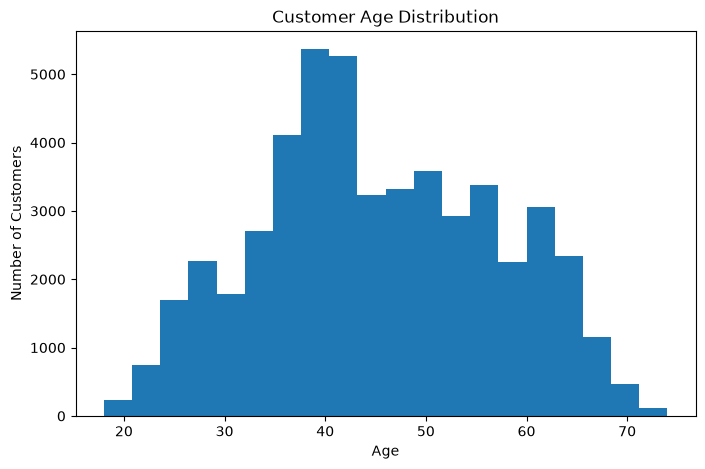

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(df["Age"], bins=20)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

In [8]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[17, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "60+"]
)

print(df["Age_Group"].value_counts().sort_index())

Age_Group
18-30     5756
31-40    13132
41-50    14384
51-60    10692
60+       6033
Name: count, dtype: int64


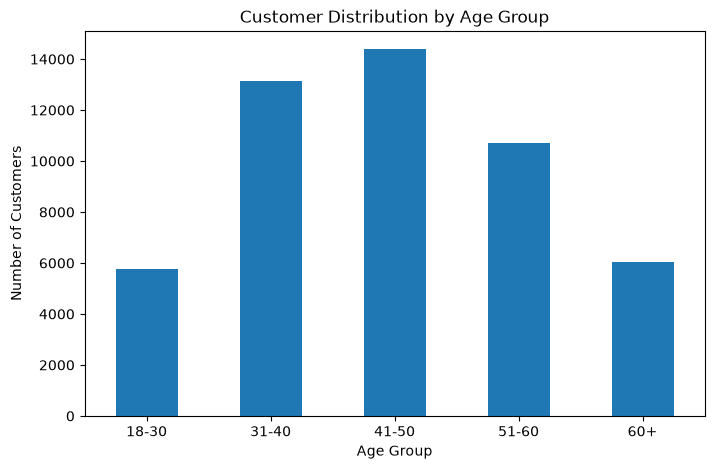

In [9]:
df["Age_Group"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

In [10]:
print(df["Income"].describe())

count     49997.000000
mean      51987.467598
std       21090.509103
min        1641.049500
25%       35469.909988
50%       51615.901476
75%       68355.126592
max      117682.951499
Name: Income, dtype: float64


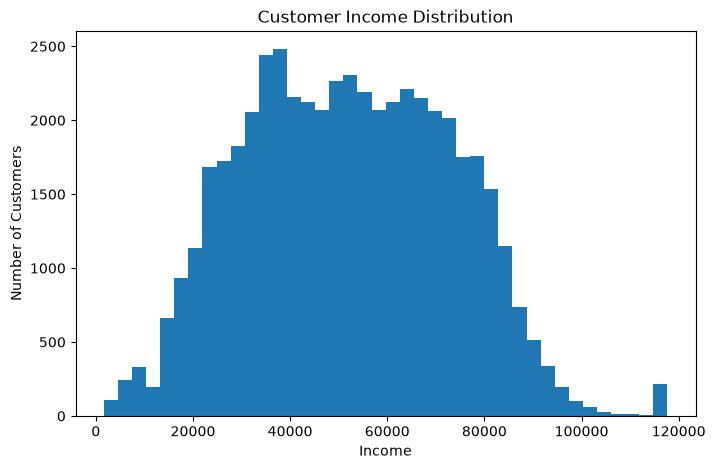

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(df["Income"], bins=40)

plt.title("Customer Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")

plt.show()

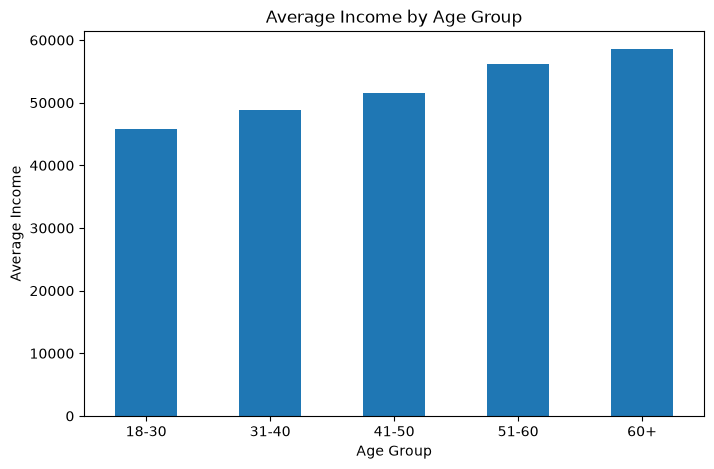

In [12]:
df.groupby("Age_Group", observed=True)["Income"].mean().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Income by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Income")
plt.xticks(rotation=0)

plt.show()

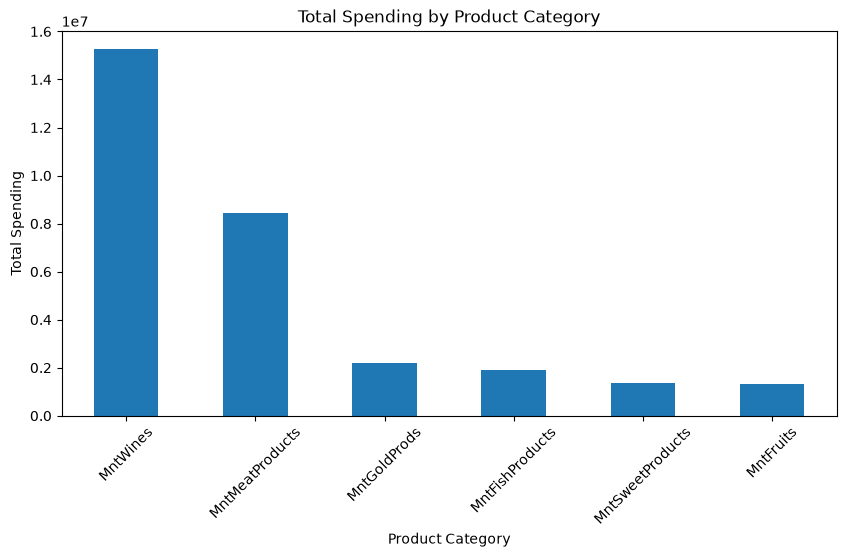

In [13]:
spending_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

spending_totals = df[spending_cols].sum().sort_values(ascending=False)

spending_totals.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Total Spending by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)

plt.show()

In [14]:
df["Total_Spending"] = df[spending_cols].sum(axis=1)

print(df["Total_Spending"].describe())

count    49997.000000
mean       609.567314
std        605.816411
min          5.000000
25%         69.000000
50%        396.000000
75%       1053.000000
max       2833.000000
Name: Total_Spending, dtype: float64


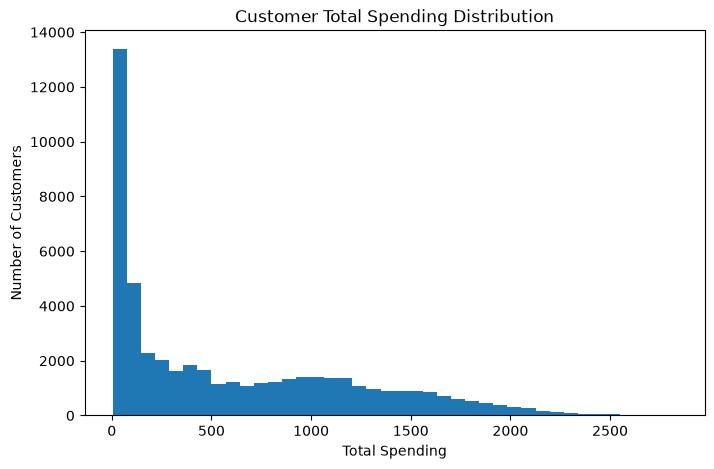

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(df["Total_Spending"], bins=40)

plt.title("Customer Total Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.show()

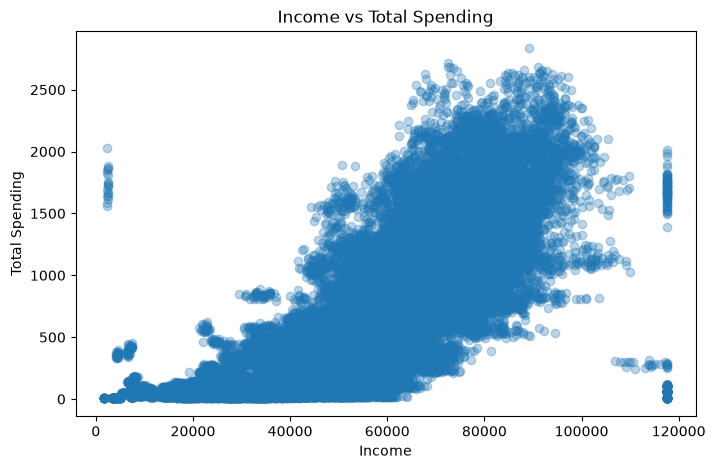

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Income"],
    df["Total_Spending"],
    alpha=0.3
)

plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")

plt.show()

In [17]:
purchase_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases"
]

df["Total_Purchases"] = df[purchase_cols].sum(axis=1)

print(df["Total_Purchases"].describe())

count    49997.000000
mean        14.921975
std          8.552681
min          0.000000
25%          8.000000
50%         14.000000
75%         21.000000
max         57.000000
Name: Total_Purchases, dtype: float64


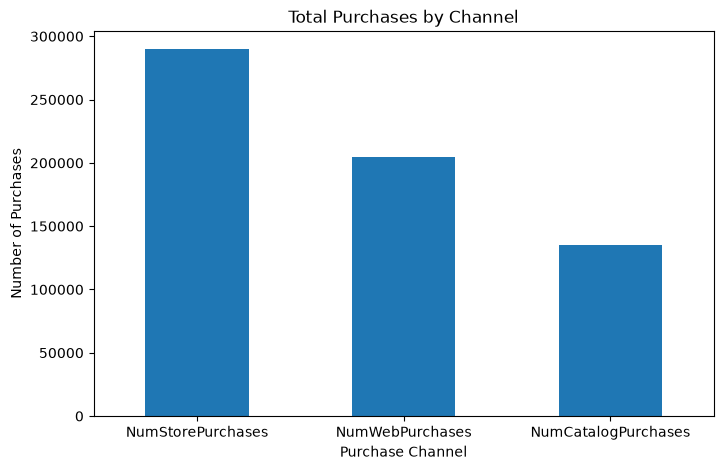

In [18]:
purchase_totals = df[
    ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
].sum().sort_values(ascending=False)

purchase_totals.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Total Purchases by Channel")
plt.xlabel("Purchase Channel")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=0)

plt.show()

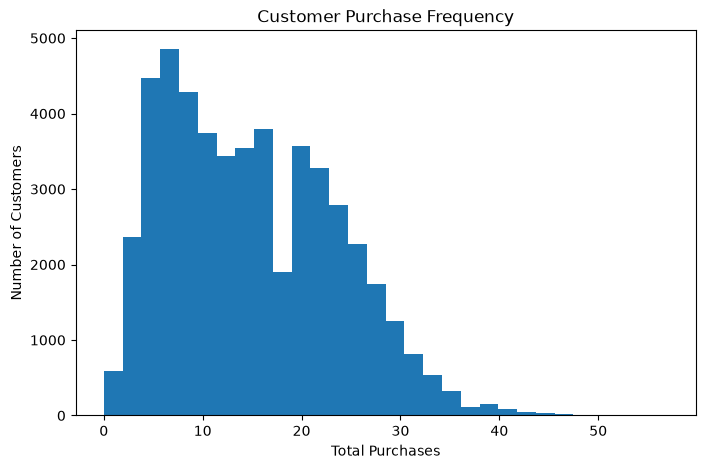

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(df["Total_Purchases"], bins=30)

plt.title("Customer Purchase Frequency")
plt.xlabel("Total Purchases")
plt.ylabel("Number of Customers")

plt.show()

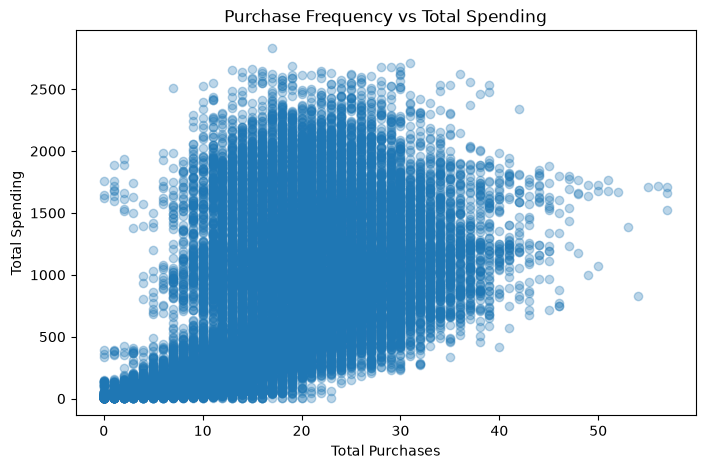

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Total_Purchases"],
    df["Total_Spending"],
    alpha=0.3
)

plt.title("Purchase Frequency vs Total Spending")
plt.xlabel("Total Purchases")
plt.ylabel("Total Spending")

plt.show()

In [21]:
print(df["Recency"].describe())

count    49997.000000
mean        49.233534
std         29.011902
min          0.000000
25%         24.000000
50%         50.000000
75%         74.000000
max         99.000000
Name: Recency, dtype: float64


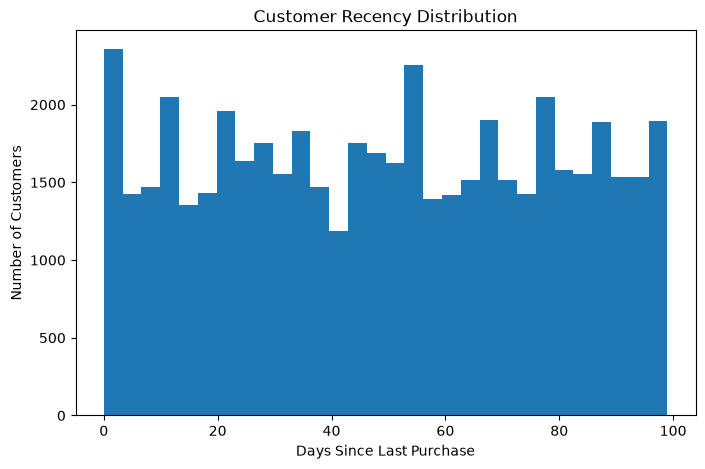

In [22]:
plt.figure(figsize=(8, 5))

plt.hist(df["Recency"], bins=30)

plt.title("Customer Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.show()

In [23]:
print(df["NumWebVisitsMonth"].describe())

count    49997.000000
mean         5.296298
std          3.314576
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         30.000000
Name: NumWebVisitsMonth, dtype: float64


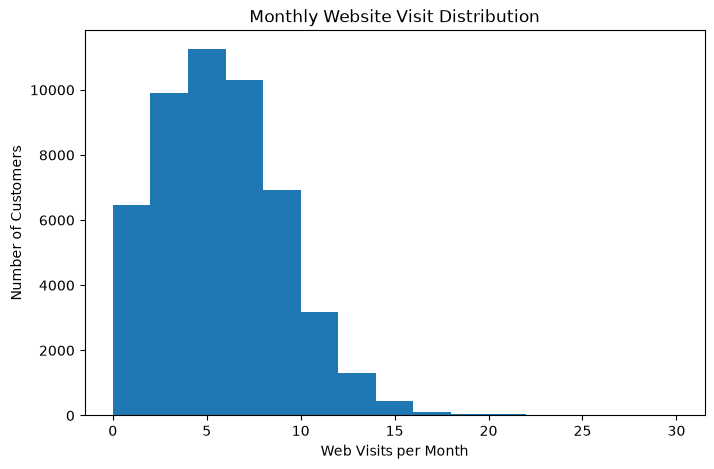

In [24]:
plt.figure(figsize=(8, 5))

plt.hist(df["NumWebVisitsMonth"], bins=15)

plt.title("Monthly Website Visit Distribution")
plt.xlabel("Web Visits per Month")
plt.ylabel("Number of Customers")

plt.show()

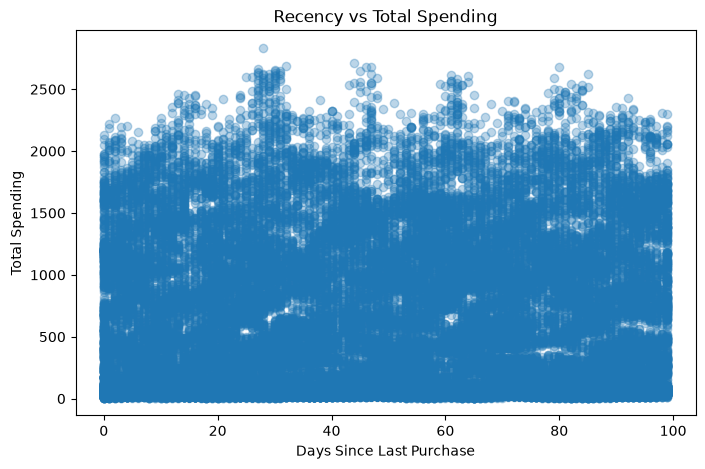

In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Recency"],
    df["Total_Spending"],
    alpha=0.3
)

plt.title("Recency vs Total Spending")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending")

plt.show()

In [27]:
important_features = [
    "Age",
    "Income",
    "Total_Spending",
    "Total_Purchases",
    "Recency",
    "NumWebVisitsMonth",
    "Kidhome",
    "Teenhome"
]

corr = df[important_features].corr()

display(corr.round(2))

,Age,Income,Total_Spending,Total_Purchases,Recency,NumWebVisitsMonth,Kidhome,Teenhome
Age,1.00,0.19,0.10,0.16,0.03,-0.08,-0.22,0.37
Income,0.19,1.00,0.80,0.60,0.01,-0.48,-0.52,0.03
Total_Spending,0.10,0.80,1.00,0.67,0.02,-0.37,-0.56,-0.14
Total_Purchases,0.16,0.60,0.67,1.00,0.01,-0.21,-0.43,0.13
Recency,0.03,0.01,0.02,0.01,1.00,-0.02,0.00,0.02
NumWebVisitsMonth,-0.08,-0.48,-0.37,-0.21,-0.02,1.00,0.33,0.10
Kidhome,-0.22,-0.52,-0.56,-0.43,0.00,0.33,1.00,-0.03
Teenhome,0.37,0.03,-0.14,0.13,0.02,0.10,-0.03,1.00


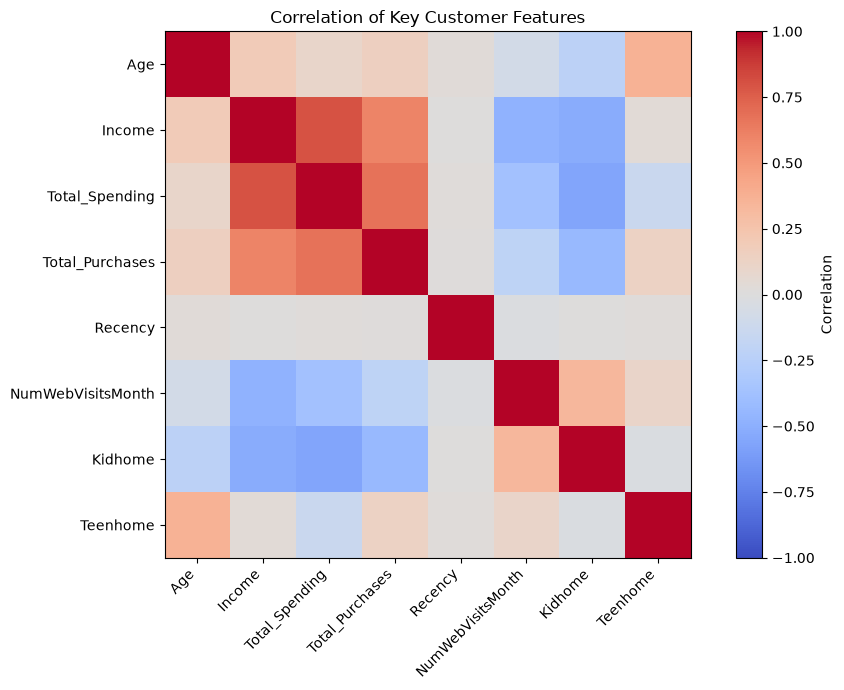

In [28]:
plt.figure(figsize=(10, 7))

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(important_features)),
    important_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(important_features)),
    important_features
)

plt.title("Correlation of Key Customer Features")

plt.tight_layout()
plt.show()